In [1]:
# =========================================================
# 05_marbert_train.ipynb
# Purpose: Fine-tune MARBERT for Algerian sentiment
# Targets neg/neu distinction where DziriBERT is weak
# =========================================================

from pathlib import Path
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)
from torch.nn import CrossEntropyLoss

print("Libraries imported successfully.")
print("PyTorch version:", torch.__version__)

Libraries imported successfully.
PyTorch version: 2.11.0+cpu


In [2]:
# Same workspace structure as your other notebooks
ML_ROOT = Path.cwd().parent

FINAL_DATA_DIR  = ML_ROOT / "data" / "final"
ARTIFACTS_DIR   = ML_ROOT / "artifacts"

final_dataset_path = FINAL_DATA_DIR / "sentiment_dataset_final.csv"

# Separate output dir — don't overwrite DziriBERT
MODEL_OUTPUT_DIR = ARTIFACTS_DIR / "marbert_sentiment_model"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset path:", final_dataset_path)
print("Model output:", MODEL_OUTPUT_DIR)

Dataset path: C:\Users\hp\Lucidia-project\ml\data\final\sentiment_dataset_final.csv
Model output: C:\Users\hp\Lucidia-project\ml\artifacts\marbert_sentiment_model


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
# Expected: cpu

Using device: cpu


In [4]:
df = pd.read_csv(final_dataset_path)
df = df[["text", "label"]].copy()
df["text"]  = df["text"].astype(str)
df["label"] = df["label"].astype(int)

print("Dataset shape:", df.shape)
print("\nLabel distribution:")
label_names = {0: "negative", 1: "neutral", 2: "positive"}
for label, count in df["label"].value_counts().sort_index().items():
    pct = count / len(df) * 100
    print(f"  {label} ({label_names[label]}): {count} ({pct:.1f}%)")

Dataset shape: (12520, 2)

Label distribution:
  0 (negative): 4658 (37.2%)
  1 (neutral): 4862 (38.8%)
  2 (positive): 3000 (24.0%)


In [5]:
id2label = {0: "negative", 1: "neutral",  2: "positive"}
label2id = {"negative": 0, "neutral":  1, "positive":  2}

print("id2label:", id2label)
print("label2id:", label2id)

id2label: {0: 'negative', 1: 'neutral', 2: 'positive'}
label2id: {'negative': 0, 'neutral': 1, 'positive': 2}


In [6]:
# Identical split strategy to DziriBERT notebook for fair comparison
X, y = df["text"], df["label"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

train_df = pd.DataFrame({"text": X_train, "label": y_train}).reset_index(drop=True)
val_df   = pd.DataFrame({"text": X_val,   "label": y_val  }).reset_index(drop=True)
test_df  = pd.DataFrame({"text": X_test,  "label": y_test }).reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 8764 | Val: 1878 | Test: 1878


In [7]:
# MARBERT from UBC-NLP — trained on 1B Arabic tweets including Algerian dialect
# Key difference from DziriBERT: much larger pretraining data, better neg/neu separation
MODEL_NAME = "UBC-NLP/MARBERT"
MAX_LENGTH = 128  # MARBERT handles longer context — Algerian complaints can be long

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("MARBERT tokenizer loaded.")
print("Vocab size:", tokenizer.vocab_size)

config.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

C:\Users\hp\Lucidia-project\ml\clean_venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\hp\.cache\huggingface\hub\models--UBC-NLP--MARBERT. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

MARBERT tokenizer loaded.
Vocab size: 100000


In [8]:
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

dataset_dict = DatasetDict({
    "train":      Dataset.from_pandas(train_df),
    "validation": Dataset.from_pandas(val_df),
    "test":       Dataset.from_pandas(test_df),
})

tokenized_datasets = dataset_dict.map(tokenize_batch, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets.set_format("torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("Tokenization done.")
print(tokenized_datasets)

Map:   0%|          | 0/8764 [00:00<?, ? examples/s]

Map:   0%|          | 0/1878 [00:00<?, ? examples/s]

Map:   0%|          | 0/1878 [00:00<?, ? examples/s]

Tokenization done.
DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 8764
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1878
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1878
    })
})


In [9]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
)
model.to(device)
print("MARBERT model loaded.")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

pytorch_model.bin:   0%|          | 0.00/654M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/654M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on yo

MARBERT model loaded.
Parameters: 162,843,651


In [10]:
# Same weighted loss as DziriBERT — positives still need extra weight
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=np.array(df["label"]),
)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("Class weights:")
for i, w in enumerate(class_weights):
    print(f"  {label_names[i]}: {w:.4f}")

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = CrossEntropyLoss(weight=class_weights_tensor)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

Class weights:
  negative: 0.8959
  neutral: 0.8584
  positive: 1.3911


In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="macro", zero_division=0,
    )
    return {
        "accuracy":         accuracy,
        "precision_macro":  precision,
        "recall_macro":     recall,
        "f1_macro":         f1,
    }

In [12]:
# warmup_steps = 10% of total steps
# total steps = (train_rows / batch_size) * epochs = (8764 / 16) * 4 ≈ 2191
# warmup = 2191 * 0.10 ≈ 219

training_args = TrainingArguments(
    output_dir=str(MODEL_OUTPUT_DIR / "checkpoints"),

    num_train_epochs=4,
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    warmup_steps=219,

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,

    weight_decay=0.01,

    use_cpu=True,
    dataloader_pin_memory=False,

    logging_strategy="epoch",
    seed=42,
    report_to="none",
)

In [13]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting MARBERT training...")
print(f"Train size: {len(train_df)} | Val size: {len(val_df)}")
train_result = trainer.train()
print("Training complete.")

Starting MARBERT training...
Train size: 8764 | Val size: 1878


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.843024,0.738137,0.652290,0.675672,0.677473,0.662218
2,0.581227,0.629768,0.711928,0.737251,0.730466,0.727969
3,0.344205,0.748290,0.720447,0.747520,0.732075,0.738856
4,0.178099,0.983557,0.724175,0.744548,0.739219,0.741775


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Training complete.


MARBERT Test Results:
              precision    recall  f1-score   support

    negative     0.6596    0.6710    0.6652       699
     neutral     0.6766    0.6516    0.6639       729
    positive     0.8516    0.8800    0.8656       450

    accuracy                         0.7135      1878
   macro avg     0.7293    0.7342    0.7316      1878
weighted avg     0.7122    0.7135    0.7127      1878



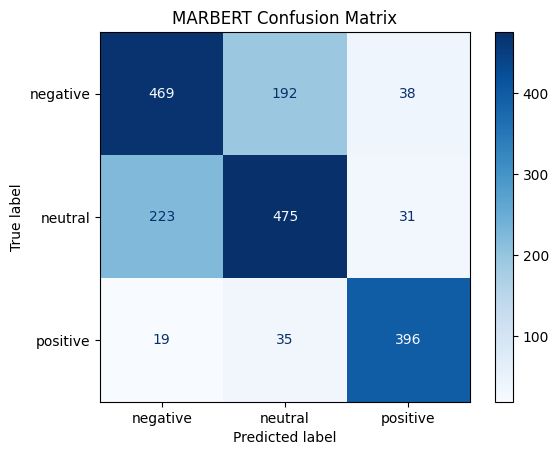

In [14]:
test_results  = trainer.predict(tokenized_datasets["test"])
test_preds    = np.argmax(test_results.predictions, axis=1)
test_labels   = test_results.label_ids

print("MARBERT Test Results:")
print(classification_report(
    test_labels, test_preds,
    target_names=["negative", "neutral", "positive"],
    digits=4
))

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
ConfusionMatrixDisplay(cm, display_labels=["negative", "neutral", "positive"]).plot(cmap="Blues")
plt.title("MARBERT Confusion Matrix")
plt.show()

In [15]:
PRODUCTION_DIR = ARTIFACTS_DIR / "production" / "marbert_v1"
PRODUCTION_DIR.mkdir(parents=True, exist_ok=True)

trainer.save_model(str(PRODUCTION_DIR))
tokenizer.save_pretrained(str(PRODUCTION_DIR))

model_meta = {
    "model_name":    "marbert_v1",
    "base_model":    "UBC-NLP/MARBERT",
    "max_length":    128,
    "num_labels":    3,
    "training_rows": 12520,
    "notes": "WeightedTrainer, augmented positives to 3000, same split as dziribert_v1"
}
with open(PRODUCTION_DIR / "model_meta.json", "w", encoding="utf-8") as f:
    json.dump(model_meta, f, ensure_ascii=False, indent=2)

label_map = {
    "id2label": {"0": "negative", "1": "neutral", "2": "positive"},
    "label2id": {"negative": 0, "neutral": 1, "positive": 2},
}
with open(PRODUCTION_DIR / "label_map.json", "w", encoding="utf-8") as f:
    json.dump(label_map, f, ensure_ascii=False, indent=2)

print("✅ MARBERT production model saved.")
print("\nFiles saved:")
for f in sorted(PRODUCTION_DIR.iterdir()):
    print(f"  {f.name:40s} {f.stat().st_size/1024:8.1f} KB")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ MARBERT production model saved.

Files saved:
  config.json                                   1.1 KB
  label_map.json                                0.2 KB
  model.safetensors                        636131.0 KB
  model_meta.json                               0.2 KB
  tokenizer.json                             2628.3 KB
  tokenizer_config.json                         0.4 KB
  training_args.bin                             5.1 KB
